In [1]:
from scripts.getQuartets import *
import numpy as np

In [2]:
def get_data(score_path="./inference_outputs/scores.txt"):
    data = {'score': [], 'polymorphism': []}
    with open(score_path) as f:
        lines = f.read().split('\n')
        N = len(lines)
        for i in range(0, N - 1, 2):
            filename = lines[i]
            s = filename.split('/')[-2]
            s = s.split('_')[0]
            score = float(lines[i + 1].split()[1])        
            data['score'].append(score * 100)
            data['polymorphism'].append(s)
            # print(s, score)
    return data


In [3]:
data = {
    'score': [],
    'polymorphism': [],
    'method': []
}

In [7]:

factors = ["0.5", "1.0"]
methods = ['ASTRAL', 'PAUP']
hue_ord = []
for f in factors:
    for m in methods:
        data_ = get_data(f"/Users/liusean/Desktop/Projects/Coding/Phylo/QuartetMethods/inference_outputs-{f}/{m}/allscores.txt")
        data['score'] += data_['score']
        data['polymorphism'] += data_['polymorphism']
        method = f'{m}-{f}' if m == 'ASTRAL' else f'MP4-{f}'
        hue_ord.append(method)
        data['method'] += [method] * len(data_['score'])

In [8]:
import seaborn as sns

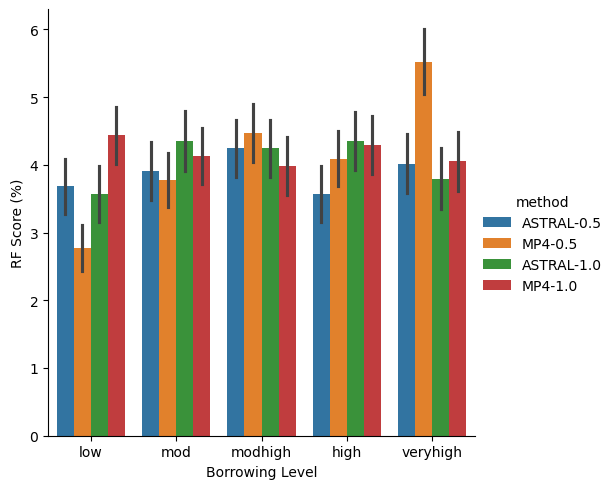

In [9]:
ax = sns.catplot(data=data, x='polymorphism', y='score', kind='bar', hue='method', hue_order=hue_ord, errorbar='se')
ax.set_ylabels("RF Score (%)")
ax.set_xlabels("Borrowing Level")
ax.set_titles("Evolution Factor = 0.5")